# Uzbekistan: what the headline numbers hide, 2010-2025

Uzbekistan's nominal GDP rose **1,643 per cent** between 2010 and 2024. This notebook
is about why that number should not be reported as growth, what is left after it is
corrected, and what the correction does to two conclusions that look solid in nominal
terms.

Three findings, in order:

1. **91 per cent of the apparent growth is the price level.** The deflated series is
   validated against the World Bank's independently published real growth rate and
   reproduces it to within 0.001 percentage points.
2. **The investment-growth correlation is spurious.** It is +0.67 on nominal series
   and +0.04 on real ones. Two soum series sharing an inflation trend co-move whether
   or not either drives the other.
3. **Regional convergence reversed in 2017.** Significant convergence before the
   currency float, significant divergence after it. The full-period regression, which
   pools both, reports nothing.

All figures come from the gold layer built by `scripts/main_pipeline.py`.

In [1]:
import sys
from pathlib import Path

# Run from the repository root, so that `scripts` is importable and the relative
# data paths resolve.
if Path.cwd().name == "notebooks":
    sys.path.insert(0, str(Path.cwd().parent))
    ROOT = Path.cwd().parent
else:
    sys.path.insert(0, str(Path.cwd()))
    ROOT = Path.cwd()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from scripts.load_data import load_panel, pivot_regional
from scripts.metrics import gini, convergence_summary, beta_convergence, sigma_convergence

pd.set_option("display.width", 120)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
})

# Nominal is always the warm colour, real is always the teal. Fixed throughout.
NOMINAL, REAL, ACCENT = "#C4622D", "#0E6E64", "#2E5C8A"

df, dim_metric, dim_region, dim_year = load_panel(data_root=ROOT / "data/gold", start=2010, end=2025)
print(f"panel: {len(df):,} rows, {df.year.min()}-{df.year.max()}, {df.metric_code.nunique()} metrics")

panel: 5,157 rows, 2010-2025, 37 metrics


## 1. The nominal illusion

`fact_economic` carries two columns for every current-price series: `value` as
published, and `real_value` in constant 2010 soums. The deflator is the World Bank
GDP deflator, rebased to 2010, and it is applied in the pipeline rather than here so
that every consumer of the gold layer gets the same numbers.

In [2]:
nat = df[df.is_national & (df.metric_code == "regional_gdp")].set_index("year").sort_index()

gdp = pd.DataFrame({
    "nominal": nat["value"],
    "real": nat["real_value"],
    "deflator": nat["gdp_deflator"],
})
gdp["nominal_idx"] = gdp["nominal"] / gdp["nominal"].loc[2010] * 100
gdp["real_idx"] = gdp["real"] / gdp["real"].loc[2010] * 100

n, r, d = (gdp.loc[2024, c] / gdp.loc[2010, c] for c in ("nominal", "real", "deflator"))
share_price = 1 - (r - 1) / (n - 1)

print(f"2010 -> 2024")
print(f"  nominal GDP     {n:6.2f}x   {(n-1)*100:+8.0f}%")
print(f"  price level     {d:6.2f}x   {(d-1)*100:+8.0f}%")
print(f"  real GDP        {r:6.2f}x   {(r-1)*100:+8.0f}%   ({(r**(1/14)-1)*100:.1f}%/yr)")
print()
print(f"  share of nominal growth that is price, not output: {share_price:.1%}")

2010 -> 2024
  nominal GDP      17.43x      +1643%
  price level       7.17x       +617%
  real GDP          2.43x       +143%   (6.6%/yr)

  share of nominal growth that is price, not output: 91.3%


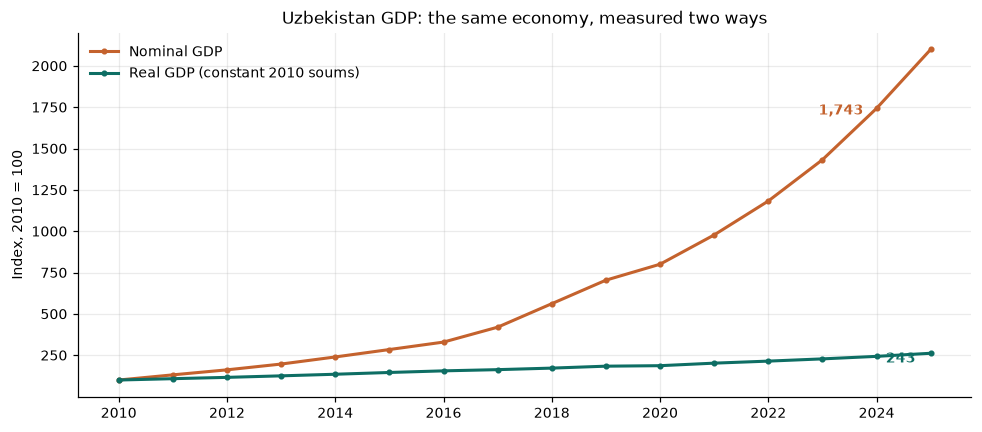

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gdp.index, gdp["nominal_idx"], color=NOMINAL, lw=2, marker="o", ms=3, label="Nominal GDP")
ax.plot(gdp.index, gdp["real_idx"], color=REAL, lw=2, marker="o", ms=3, label="Real GDP (constant 2010 soums)")
ax.set(xlabel="", ylabel="Index, 2010 = 100",
       title="Uzbekistan GDP: the same economy, measured two ways")
ax.legend(frameon=False)
ax.annotate(f"{gdp['nominal_idx'].loc[2024]:,.0f}", (2024, gdp["nominal_idx"].loc[2024]),
            textcoords="offset points", xytext=(-38, -4), color=NOMINAL, fontweight="bold")
ax.annotate(f"{gdp['real_idx'].loc[2024]:,.0f}", (2024, gdp["real_idx"].loc[2024]),
            textcoords="offset points", xytext=(6, -4), color=REAL, fontweight="bold")
plt.tight_layout(); plt.show()

The axis is linear on purpose. A log scale would compress the gap into something
comfortable to read, which is the impression this chart exists to correct.

### Validating the deflation

Applying a deflator is easy; applying the right one is the question. The check is
whether the deflated series reproduces a real growth rate published independently.

In [4]:
check = pd.DataFrame({
    "nominal_growth": gdp["nominal"].pct_change() * 100,
    "deflated_growth": gdp["real"].pct_change() * 100,
    "worldbank_real": nat["real_gdp_growth_pct"],
})
check["gap_pp"] = check["deflated_growth"] - check["worldbank_real"]
print(check.loc[2011:2024].round(2).to_string())
print(f"\nmean absolute gap: {check.loc[2011:2024,'gap_pp'].abs().mean():.4f} pp")

      nominal_growth  deflated_growth  worldbank_real  gap_pp
year                                                         
2011           31.24             8.13            8.13    -0.0
2012           23.10             7.36            7.36    -0.0
2013           21.69             7.92            7.92     0.0
2014           21.82             7.71            7.71    -0.0
2015           18.74             7.94            7.94    -0.0
2016           15.83             6.71            6.71    -0.0
2017           27.36             4.70            4.70     0.0
2018           33.87             5.72            5.72    -0.0
2019           25.32             6.79            6.79    -0.0
2020           13.71             1.62            1.62     0.0
2021           22.14             8.20            8.20    -0.0
2022           20.98             6.09            6.09    -0.0
2023           21.11             6.32            6.32     0.0
2024           21.69             6.68            6.68    -0.0

mean ab

Zero to four decimal places across fourteen years. The deflation is correct.

### What that does to the story about 2017

The reform period is where the two measures disagree most, and they disagree in
opposite directions.

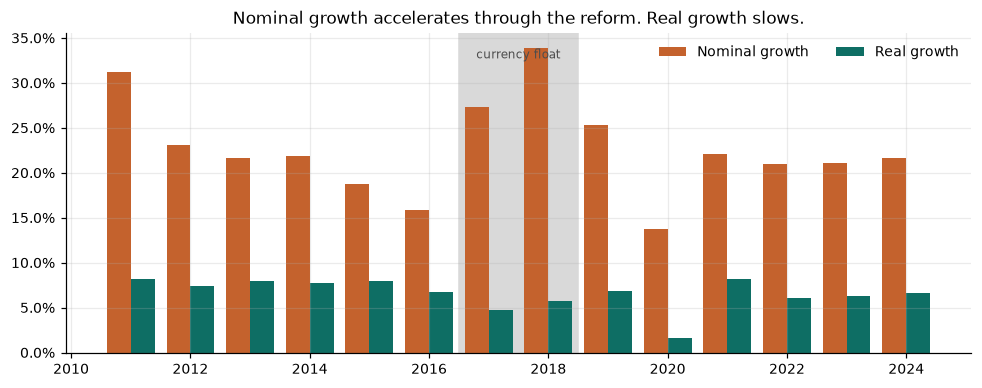

  2016: nominal  15.8%   real  6.7%
  2017: nominal  27.4%   real  4.7%
  2018: nominal  33.9%   real  5.7%


In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(2011, 2025); w = 0.4
ax.bar(x - w/2, check.loc[2011:2024, "nominal_growth"], w, color=NOMINAL, label="Nominal growth")
ax.bar(x + w/2, check.loc[2011:2024, "deflated_growth"], w, color=REAL, label="Real growth")
ax.axvspan(2016.5, 2018.5, color="0.85", zorder=0)
ax.text(2017.5, ax.get_ylim()[1]*0.92, "currency float", ha="center", fontsize=8, color="0.3")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(xlabel="", ylabel="", title="Nominal growth accelerates through the reform. Real growth slows.")
ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

for y in (2016, 2017, 2018):
    print(f"  {y}: nominal {check.loc[y,'nominal_growth']:5.1f}%   real {check.loc[y,'deflated_growth']:4.1f}%")

The som was floated in September 2017, moving from roughly 4,200 to 8,100 per dollar.
That devaluation passes straight into a price level measured in soums, and every soum
series inflates with it.

So the "post-2016 acceleration" visible in the nominal data is the currency regime
changing. Real growth over the same two years is the weakest in the series outside
the pandemic.

## 2. A correlation that does not survive deflation

The relationship between investment and growth is the standard place to look for the
driver of an expansion. In nominal terms it looks strong.

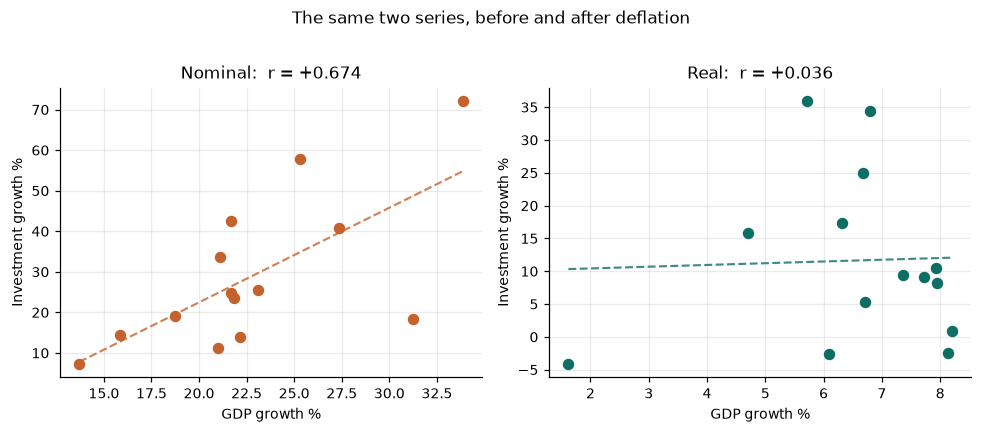

nominal r = +0.674
real    r = +0.036


In [6]:
inv = df[df.is_national & (df.metric_code == "fixed_capital_investment")].set_index("year").sort_index()

pairs = pd.DataFrame({
    "gdp_nominal": gdp["nominal"].pct_change(),
    "inv_nominal": inv["value"].pct_change(),
    "gdp_real": gdp["real"].pct_change(),
    "inv_real": inv["real_value"].pct_change(),
}).loc[2011:2024]

r_nom = pairs.gdp_nominal.corr(pairs.inv_nominal)
r_real = pairs.gdp_real.corr(pairs.inv_real)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=False)
for ax, (gx, iy), c, lab, rr in [
    (axes[0], ("gdp_nominal", "inv_nominal"), NOMINAL, "Nominal", r_nom),
    (axes[1], ("gdp_real", "inv_real"), REAL, "Real", r_real),
]:
    ax.scatter(pairs[gx]*100, pairs[iy]*100, color=c, s=42, zorder=3)
    m, b = np.polyfit(pairs[gx]*100, pairs[iy]*100, 1)
    xs = np.linspace((pairs[gx]*100).min(), (pairs[gx]*100).max(), 20)
    ax.plot(xs, m*xs + b, color=c, lw=1.4, ls="--", alpha=.8)
    ax.set(xlabel="GDP growth %", ylabel="Investment growth %", title=f"{lab}:  r = {rr:+.3f}")
fig.suptitle("The same two series, before and after deflation", y=1.02)
plt.tight_layout(); plt.show()

print(f"nominal r = {r_nom:+.3f}")
print(f"real    r = {r_real:+.3f}")

The nominal correlation of **+0.67** is a shared trend, not a relationship. Both
series are denominated in a currency that lost most of its value over the period, so
both rise together for a reason that has nothing to do with investment financing
output. Deflate both and **+0.04** is left: no relationship at all in these data.

This is the classic spurious regression between two series carrying a common trend.
It is worth being clear about what the result does and does not say. It does not show
that investment is irrelevant to growth in Uzbekistan; fourteen annual observations
could not establish that either way. It shows that the nominal correlation is not
evidence for it, which is the claim that was actually being made.

The share-of-GDP measure sidesteps the problem entirely: a ratio of two nominal
quantities from the same year needs no deflator, because the price level cancels.

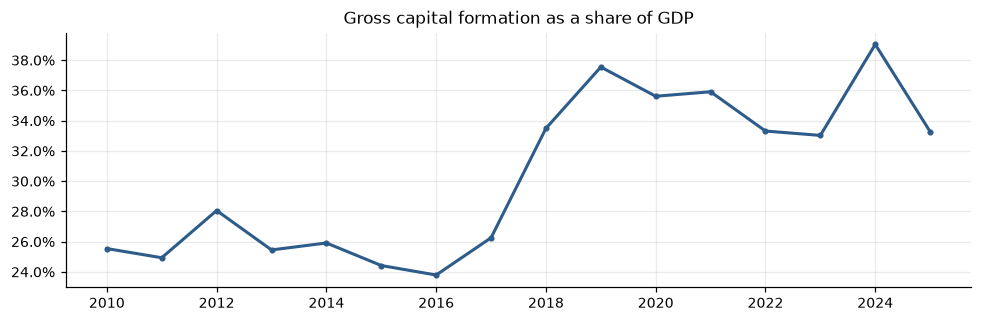

year
2010    25.5
2016    23.8
2017    26.3
2020    35.6
2024    39.0


In [7]:
share = df[df.is_national & (df.metric_code == "wb_capital_formation_pct_gdp")].set_index("year")["value"]
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(share.index, share.values, color=ACCENT, lw=2, marker="o", ms=3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Gross capital formation as a share of GDP", ylabel="", xlabel="")
plt.tight_layout(); plt.show()
print(share.loc[[2010, 2016, 2017, 2020, 2024]].round(1).to_string())

## 3. The long view, 1987-2025

The stat.uz regional series begin in 2010. The World Bank national series reach back
to 1987, four years before independence, which puts the 2017 reform in a frame long
enough to judge it against.

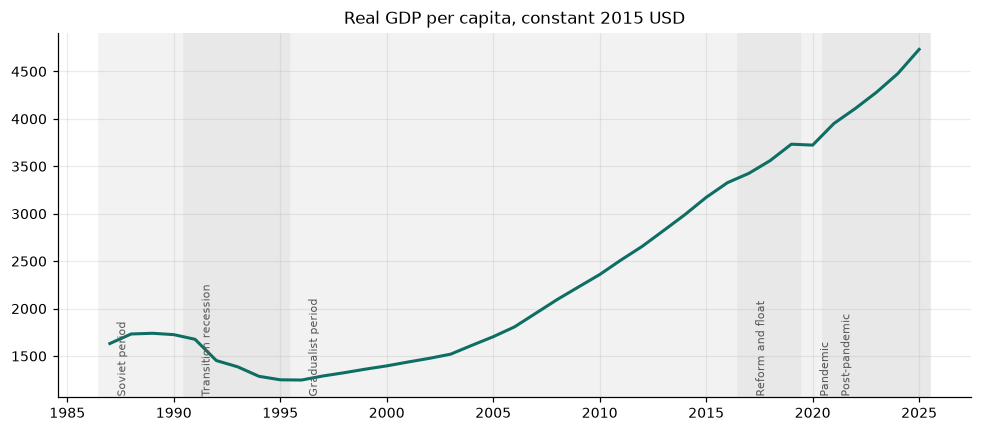

In [8]:
long_df, _, _, _ = load_panel(data_root=ROOT / "data/gold", start=1987, end=2025, grain="national")
wide = long_df.pivot_table(index="year", columns="metric_code", values="value")

eras = long_df.drop_duplicates("year").set_index("year")["policy_era"].sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
pc = wide["wb_real_gdp_per_capita"].dropna()
ax.plot(pc.index, pc.values, color=REAL, lw=2)

shades = ["#f2f2f2", "#e8e8e8"]
for i, era in enumerate(sorted(eras.unique())):
    yrs = eras[eras == era].index
    ax.axvspan(yrs.min()-.5, yrs.max()+.5, color=shades[i % 2], zorder=0)
    ax.text(yrs.min()+.3, ax.get_ylim()[0], era.split(". ")[1],
            rotation=90, va="bottom", fontsize=7, color="0.35")

ax.set(title="Real GDP per capita, constant 2015 USD", ylabel="", xlabel="")
plt.tight_layout(); plt.show()

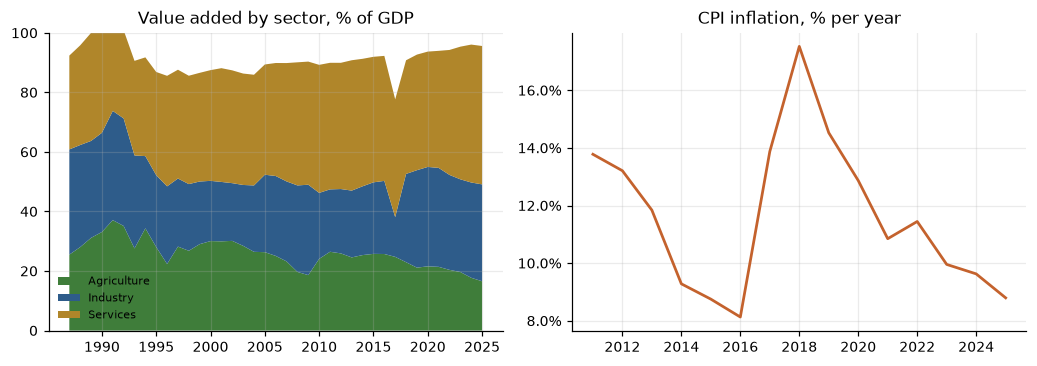

agriculture share 1987: 25.5%  ->  2025: 16.6%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))

sect = wide[["wb_agriculture_pct_gdp", "wb_industry_pct_gdp", "wb_services_pct_gdp"]].dropna()
axes[0].stackplot(sect.index, sect.T.values, colors=["#3F7D3A", ACCENT, "#B0862A"],
                  labels=["Agriculture", "Industry", "Services"])
axes[0].set(title="Value added by sector, % of GDP", ylim=(0, 100))
axes[0].legend(loc="lower left", fontsize=7, frameon=False)

infl = wide["wb_inflation_cpi_pct"].dropna()
axes[1].plot(infl.index, infl.values, color=NOMINAL, lw=1.8)
axes[1].set(title="CPI inflation, % per year")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()

a0, a1 = sect["wb_agriculture_pct_gdp"].iloc[0], sect["wb_agriculture_pct_gdp"].iloc[-1]
print(f"agriculture share {sect.index[0]}: {a0:.1f}%  ->  {sect.index[-1]}: {a1:.1f}%")

The inflation panel is why the 2017 devaluation reads as a shock in a 2010-based
chart and as a modest bump in a 1990-based one. Uzbekistan has been through far worse
price instability, and any series indexed only to 2010 hides that.

## 4. Regional convergence, and where it reversed

The question is not whether the country grew, but whether growth reached the regions
that started behind.

Two choices decide whether the answer means anything. Inequality has to be measured
on **real** values, or it partly measures the price level; and on a **per capita**
basis, or it mostly measures which regions are populous. The gold layer carries
`real_value_per_capita` for exactly this.

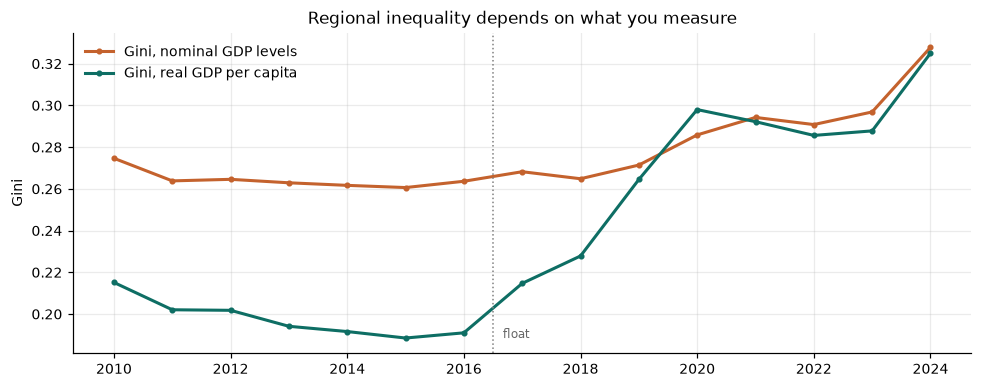

      Gini, nominal GDP levels  Gini, real GDP per capita
year                                                     
2010                     0.275                      0.215
2016                     0.264                      0.191
2024                     0.328                      0.325


In [10]:
pc_reg = pivot_regional(df, "regional_gdp", value_col="real_value_per_capita")
lv_reg = pivot_regional(df, "regional_gdp", value_col="value")

ineq = pd.DataFrame({
    "Gini, nominal GDP levels": [gini(lv_reg.loc[y].dropna().values) for y in lv_reg.index],
    "Gini, real GDP per capita": [gini(pc_reg.loc[y].dropna().values) for y in pc_reg.index],
}, index=pc_reg.index).loc[2010:2024]

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(ineq.index, ineq.iloc[:, 0], color=NOMINAL, lw=2, marker="o", ms=3, label=ineq.columns[0])
ax.plot(ineq.index, ineq.iloc[:, 1], color=REAL, lw=2, marker="o", ms=3, label=ineq.columns[1])
ax.axvline(2016.5, color="0.5", ls=":", lw=1)
ax.text(2016.6, ineq.values.min(), " float", fontsize=8, color="0.4")
ax.set(title="Regional inequality depends on what you measure", ylabel="Gini", xlabel="")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(ineq.loc[[2010, 2016, 2024]].round(3).to_string())

The nominal-levels measure drifts upward and reads as slow structural change. The
real per-capita measure **falls** to 2016 and then climbs steeply, which is a
different shape with a turning point in it.

The formal test for that turning point is beta-convergence: regress each region's
annualised growth on its starting level. A negative coefficient means regions that
started poorer grew faster.

In [11]:
summary = convergence_summary(pc_reg, {
    "Full period": (2010, 2024),
    "Pre-reform":  (2010, 2016),
    "Post-float":  (2017, 2024),
})
print(summary[["start", "end", "beta", "p_value", "r_squared", "verdict"]].round(4).to_string())

             start   end    beta  p_value  r_squared                      verdict
period                                                                           
Full period   2010  2024  0.0249   0.0523     0.2787  no significant relationship
Pre-reform    2010  2016 -0.0225   0.0399     0.3067                  convergence
Post-float    2017  2024  0.0590   0.0017     0.5741                   divergence


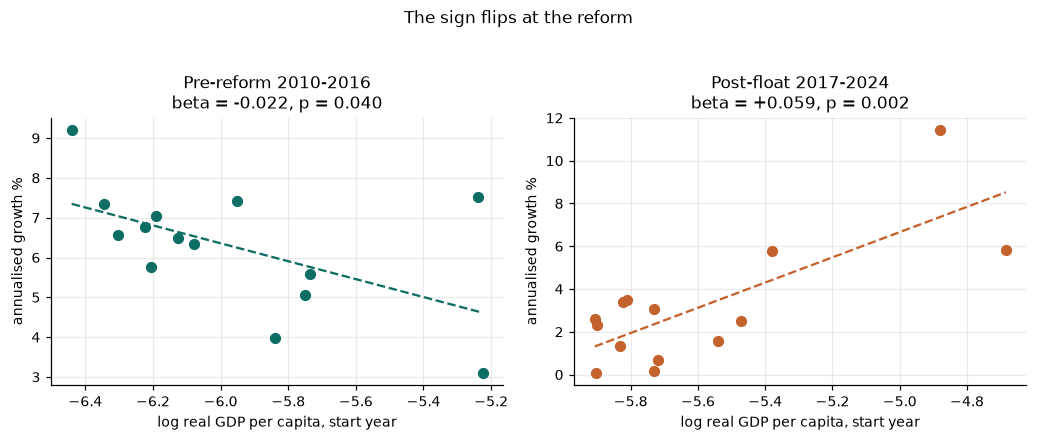

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
for ax, (label, (s, e), col) in zip(axes, [
    ("Pre-reform 2010-2016", (2010, 2016), REAL),
    ("Post-float 2017-2024", (2017, 2024), NOMINAL),
]):
    model, data = beta_convergence(pc_reg, s, e)
    ax.scatter(data.log_initial, data.growth * 100, color=col, s=40, zorder=3)
    xs = np.linspace(data.log_initial.min(), data.log_initial.max(), 20)
    ax.plot(xs, (model.params["const"] + model.params["log_initial"] * xs) * 100,
            color=col, lw=1.5, ls="--")
    b, p = model.params["log_initial"], model.pvalues["log_initial"]
    ax.set(title=f"{label}\nbeta = {b:+.3f}, p = {p:.3f}",
           xlabel="log real GDP per capita, start year", ylabel="annualised growth %")
fig.suptitle("The sign flips at the reform", y=1.04)
plt.tight_layout(); plt.show()

Convergence before, divergence after, both significant at 5 per cent.

The full-period regression returns **beta = +0.025, p = 0.052** — nothing
significant. That is not an absence of dynamics. It is two opposite regimes averaging
each other out, and it is the reason the sample has to be split at a date chosen for
a reason rather than fitted.

Sigma-convergence, which asks only whether the spread is narrowing, agrees.

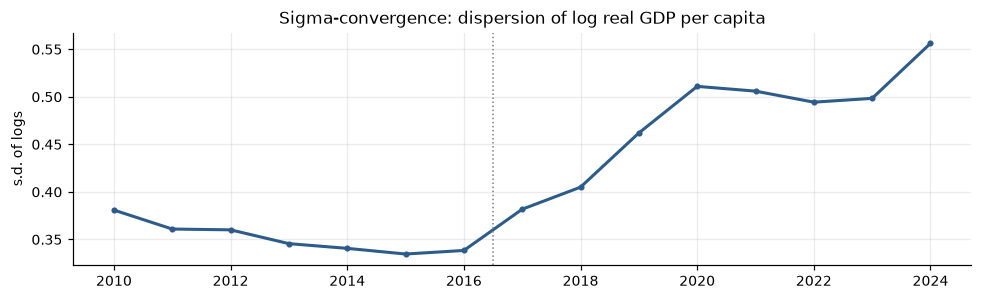

2010 0.381  ->  2016 0.338  (narrowing)
2016 0.338  ->  2024 0.556  (widening)


In [13]:
sig = sigma_convergence(pc_reg).loc[2010:2024]
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(sig.index, sig.log_sd, color=ACCENT, lw=2, marker="o", ms=3)
ax.axvline(2016.5, color="0.5", ls=":", lw=1)
ax.set(title="Sigma-convergence: dispersion of log real GDP per capita", ylabel="s.d. of logs", xlabel="")
plt.tight_layout(); plt.show()

print(f"2010 {sig.log_sd.loc[2010]:.3f}  ->  2016 {sig.log_sd.loc[2016]:.3f}  (narrowing)")
print(f"2016 {sig.log_sd.loc[2016]:.3f}  ->  2024 {sig.log_sd.loc[2024]:.3f}  (widening)")

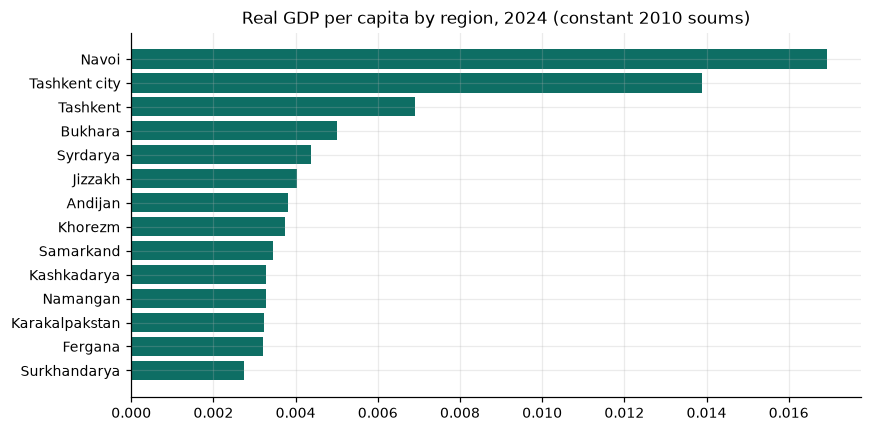

ratio, highest to lowest region: 6.17x


In [14]:
latest = 2024
bars = pc_reg.loc[latest].dropna().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(bars.index, bars.values, color=REAL)
ax.set(title=f"Real GDP per capita by region, {latest} (constant 2010 soums)", xlabel="", ylabel="")
plt.tight_layout(); plt.show()
print(f"ratio, highest to lowest region: {bars.max()/bars.min():.2f}x")

## What this leaves

**On method.** The pipeline that produced the original version of this analysis was
sound: the joins were correct, the grain was unique, referential integrity held, and
every conclusion drawn from it was wrong in the same way. Nothing in a data-quality
framework catches a series compared against itself across a sevenfold change in the
price level, because nothing about it is malformed. The check that caught it was
knowing that stat.uz publishes at current prices and that the som was floated in 2017.

**On the findings.**

- Real growth over 2010-2024 averages 6.6 per cent a year, which is strong. It is not
  the 22.6 per cent the nominal series implies, and the difference is not a rounding
  question — it is the difference between an economy tripling and one growing
  seventeenfold.
- The evidence that investment drove the expansion does not survive deflation. The
  share-of-GDP series is the better instrument and does not show the same story.
- Regional convergence ran until 2016 and reversed after the float. Beta, sigma and
  the Gini agree on the timing, and the full-period regression conceals it.

**What would strengthen it.** A regional deflator, if one is ever published — the
national deflator is applied uniformly here, which understates real growth in regions
with faster local inflation. A longer regional panel; fourteen observations per
regression is few. And a decomposition of the divergence into sectoral versus
demographic causes, which the current metric set cannot support.